In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define filenames
filenames = ['N001_011.csv', 'N002_011.csv', 'N003_011.csv', 'N004_011.csv']
data_list = []



In [2]:
# Step 1: Load and extract columns 2~4 (index 1:4)
for file in filenames:
    df = pd.read_csv(file)
    acc = df.iloc[:, 1:4].values  # Extract XYZ acceleration
    data_list.append(acc)



[Saved] 'ambient_vib_wsn.npy' with shape (41999, 12)


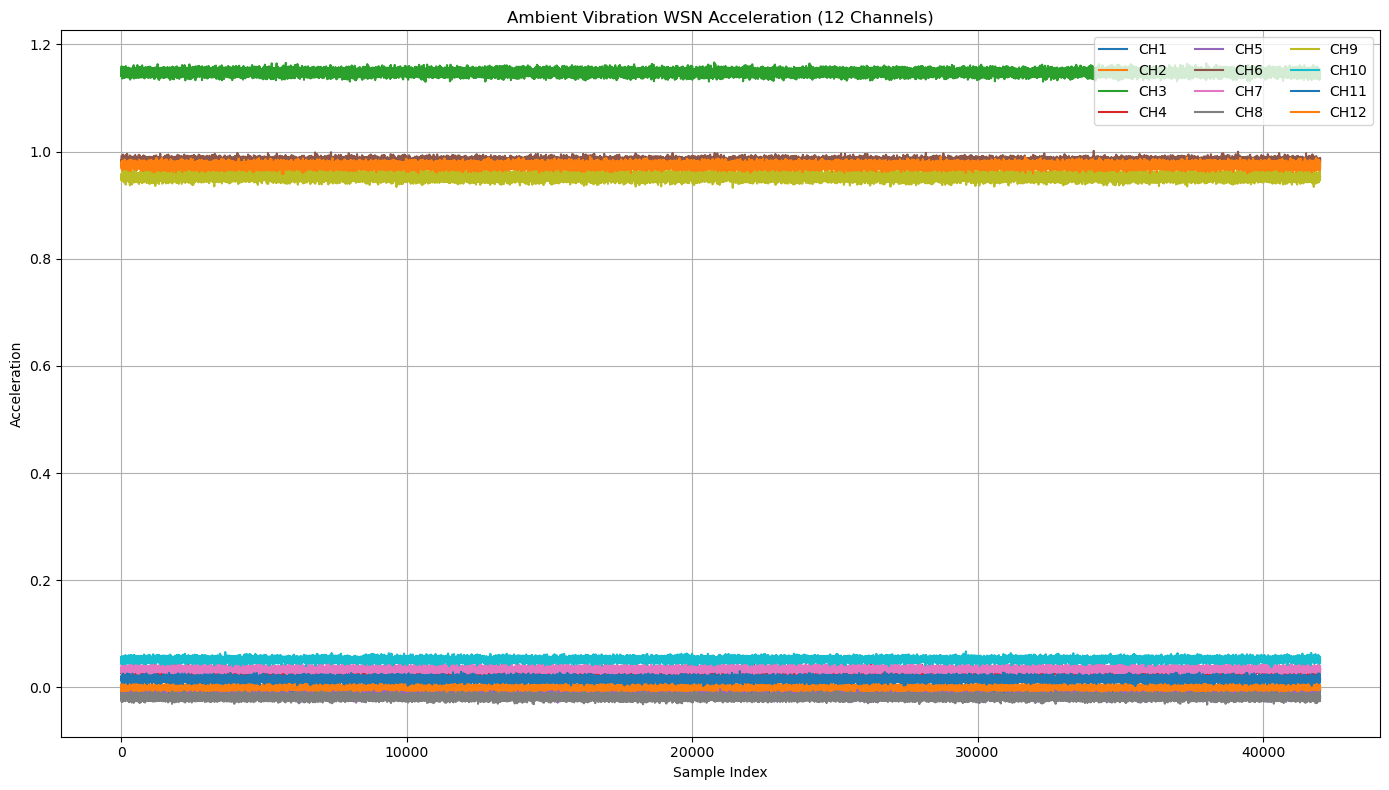

In [ ]:
# Step 2: Concatenate to shape (n_samples, 12)
ambient_vib_wsn = np.hstack(data_list)  # shape: (samples, 12)
np.save('ambient_vib_wsn.npy', ambient_vib_wsn)
print(f"[Saved] 'ambient_vib_wsn.npy' with shape {ambient_vib_wsn.shape}")

# Step 3: Plot 12 time-history curves
plt.figure(figsize=(14, 8))
n_channels = ambient_vib_wsn.shape[1]
time = np.arange(ambient_vib_wsn.shape[0])  # sample index as time axis

for i in range(n_channels):
    plt.plot(time, ambient_vib_wsn[:, i], label=f"CH{i+1}")

plt.title("Ambient Vibration WSN Acceleration (12 Channels)")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration")
plt.legend(loc='upper right', ncol=3)
plt.tight_layout()
plt.grid(True)
plt.show()


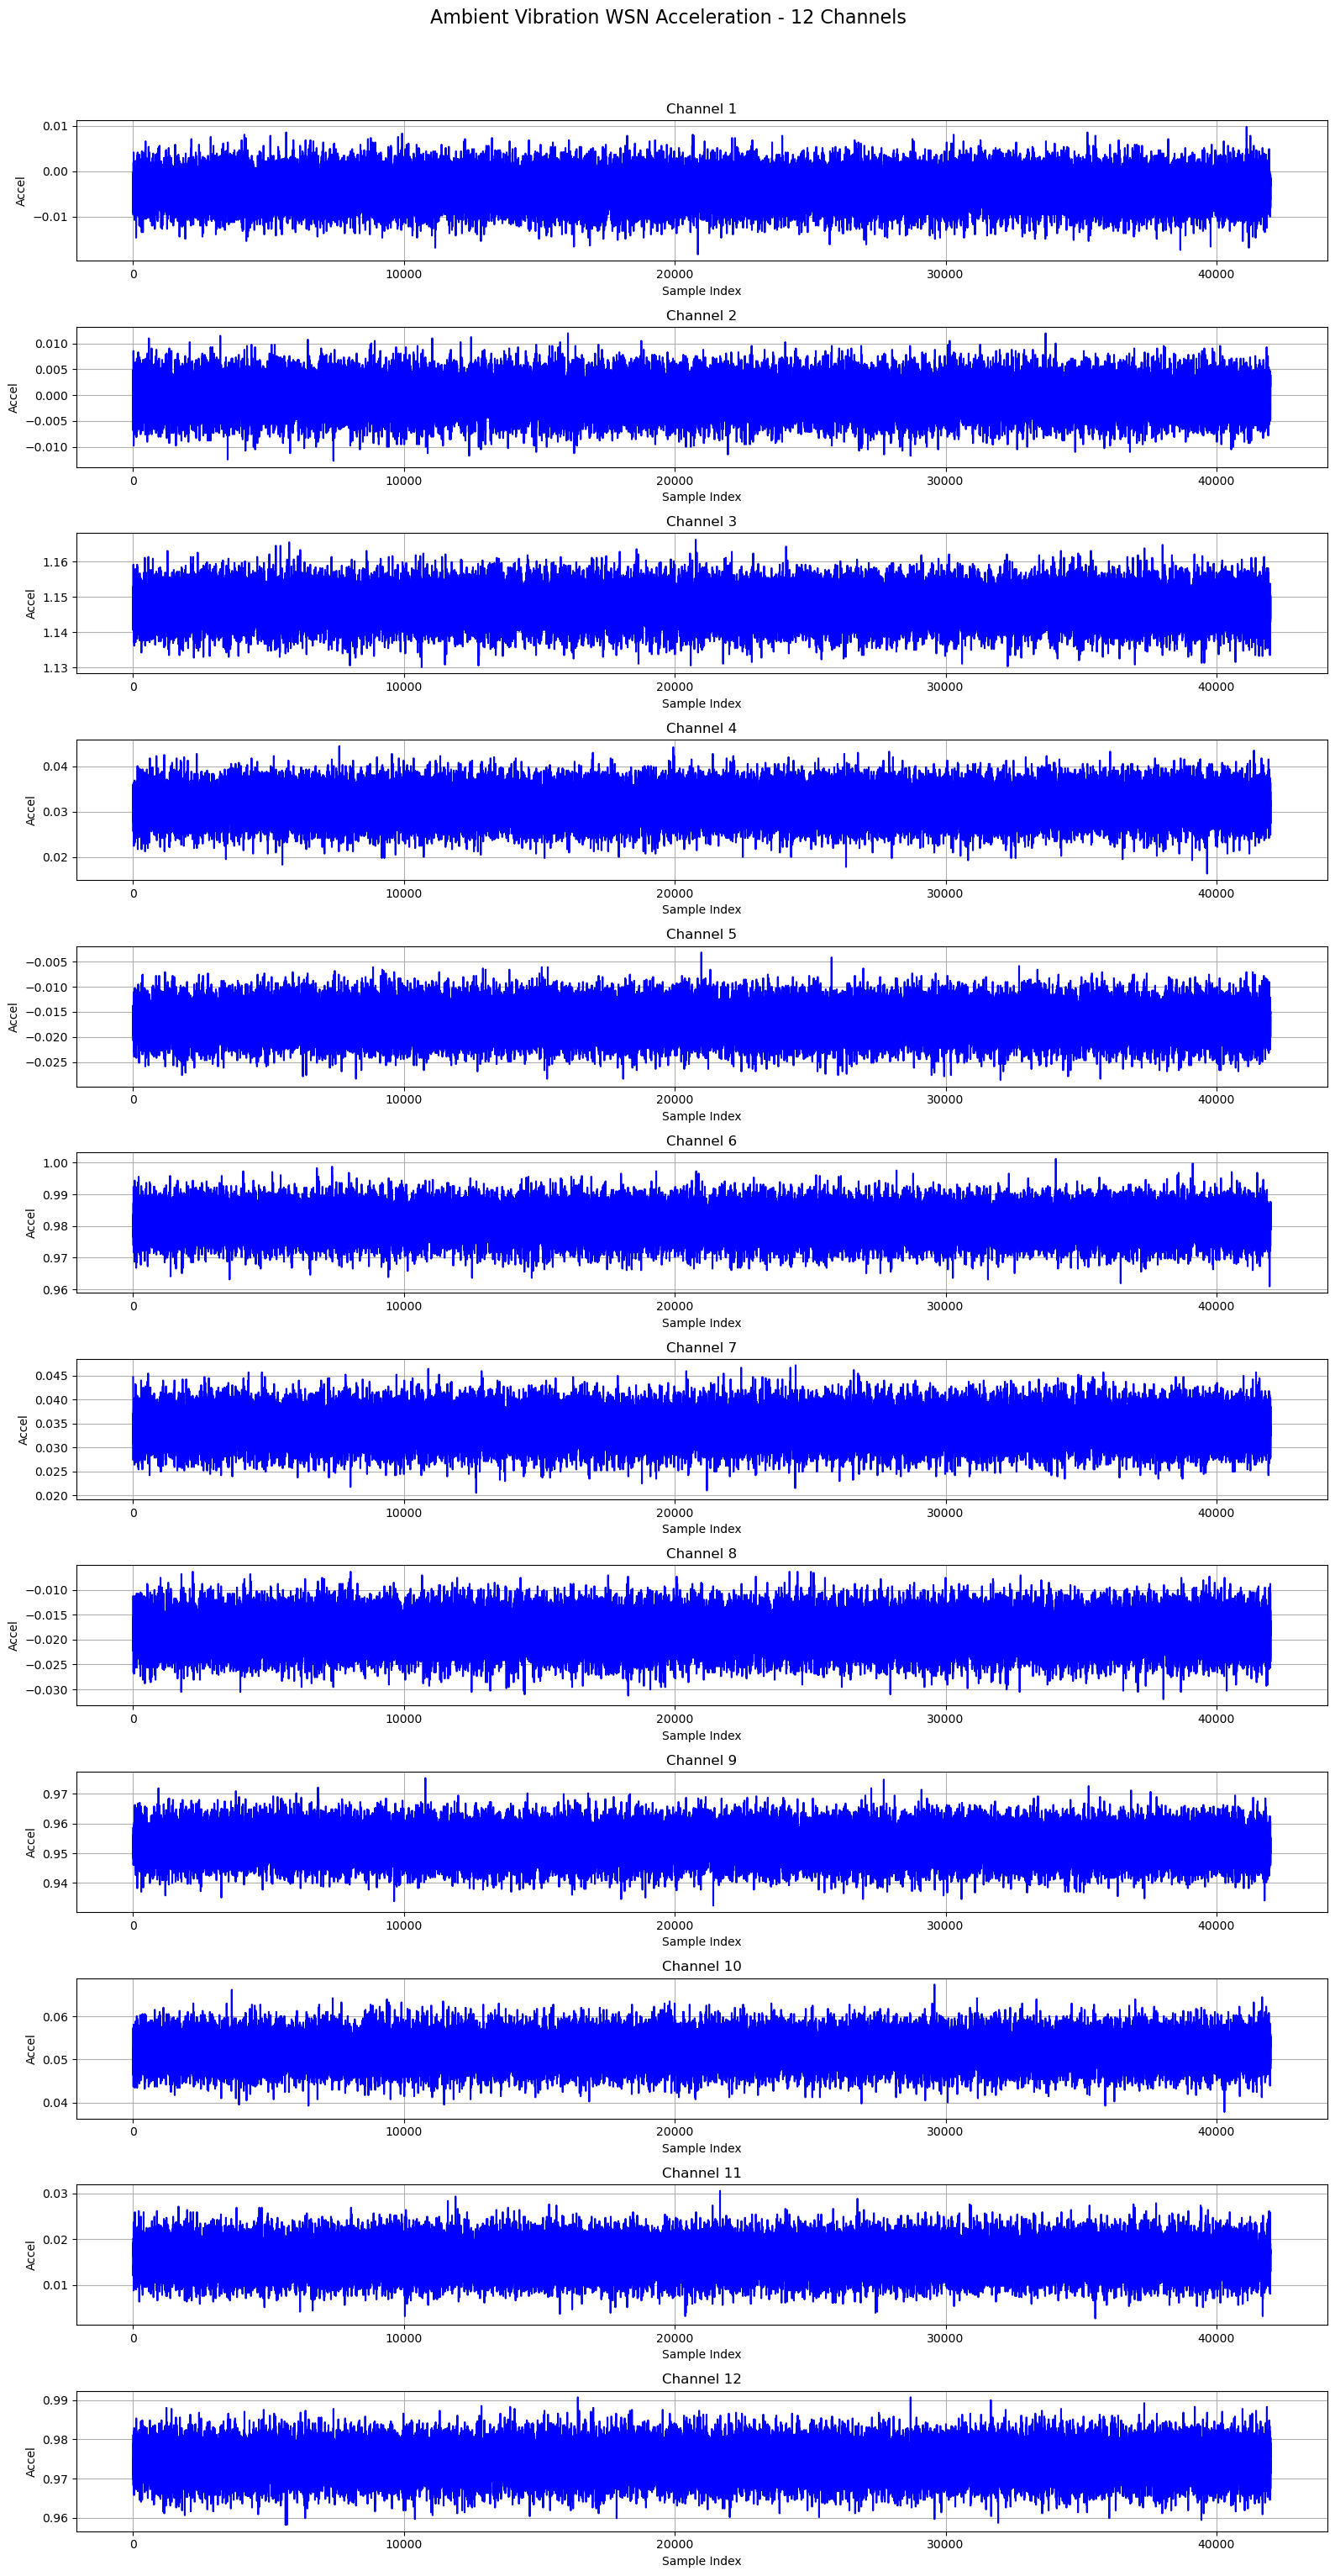

In [6]:
import matplotlib.pyplot as plt

# Step 3: Plot 12 time-history curves using subplots
n_channels = ambient_vib_wsn.shape[1]
time = np.arange(ambient_vib_wsn.shape[0])  # sample index as time axis

plt.figure(figsize=(16, 30))  # Adjust as needed

for i in range(n_channels):
    plt.subplot(12, 1, i + 1)
    plt.plot(time, ambient_vib_wsn[:, i], color='blue')
    plt.title(f"Channel {i+1}")
    plt.xlabel("Sample Index")
    plt.ylabel("Accel")
    plt.grid(True)
    plt.tight_layout()

plt.suptitle("Ambient Vibration WSN Acceleration - 12 Channels", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


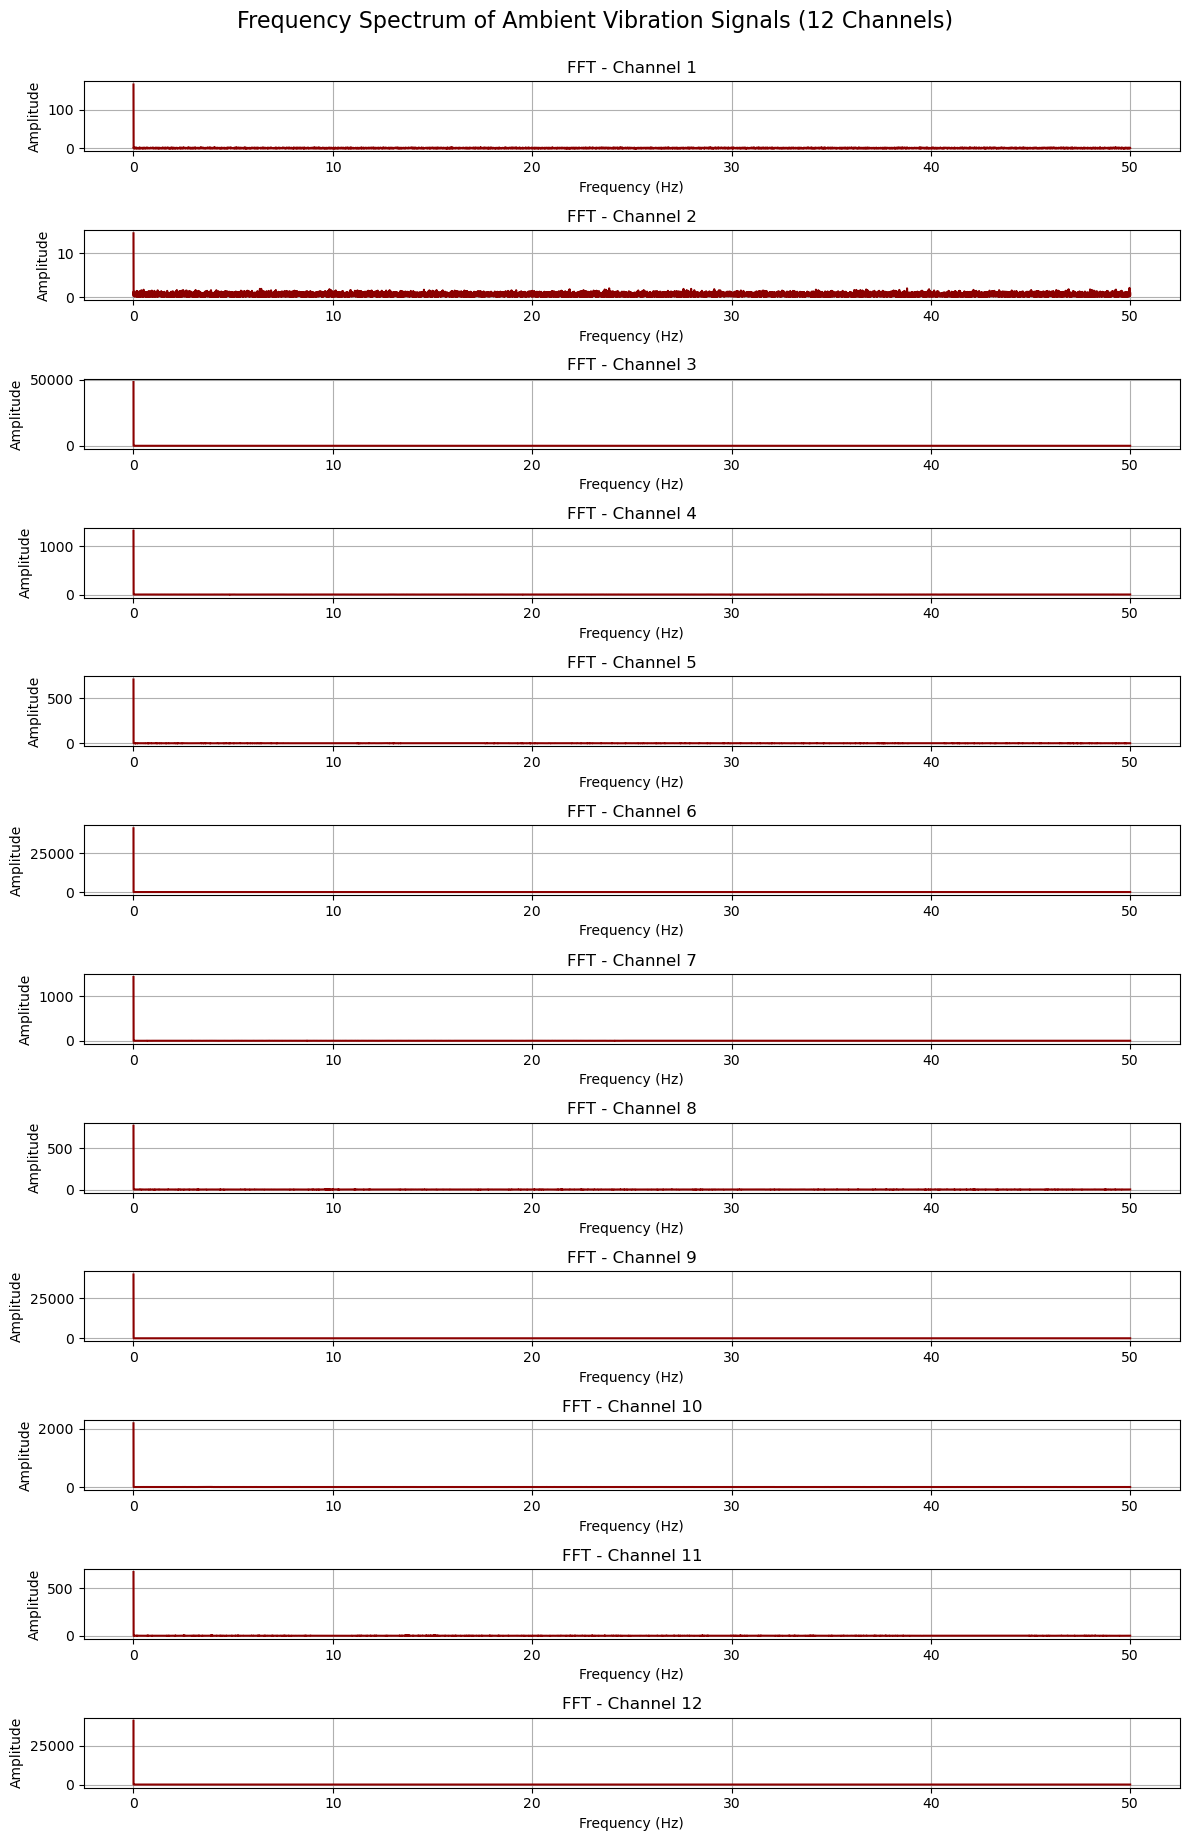

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling frequency
fs = 100  # Hz
n_samples = ambient_vib_wsn.shape[0]
n_channels = ambient_vib_wsn.shape[1]

# Frequency axis (one-sided)
freqs = np.fft.rfftfreq(n_samples, d=1/fs)

# Compute FFT and magnitude spectrum for each channel
fft_data = [np.abs(np.fft.rfft(ambient_vib_wsn[:, i])) for i in range(n_channels)]

# Plot FFT results in 12x1 subplots
plt.figure(figsize=(12, 18))  # Wide and tall figure

for i in range(n_channels):
    plt.subplot(12, 1, i + 1)
    plt.plot(freqs, fft_data[i], color='darkred')
    plt.title(f"FFT - Channel {i+1}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Frequency Spectrum of Ambient Vibration Signals (12 Channels)", fontsize=16, y=1.02)
plt.show()


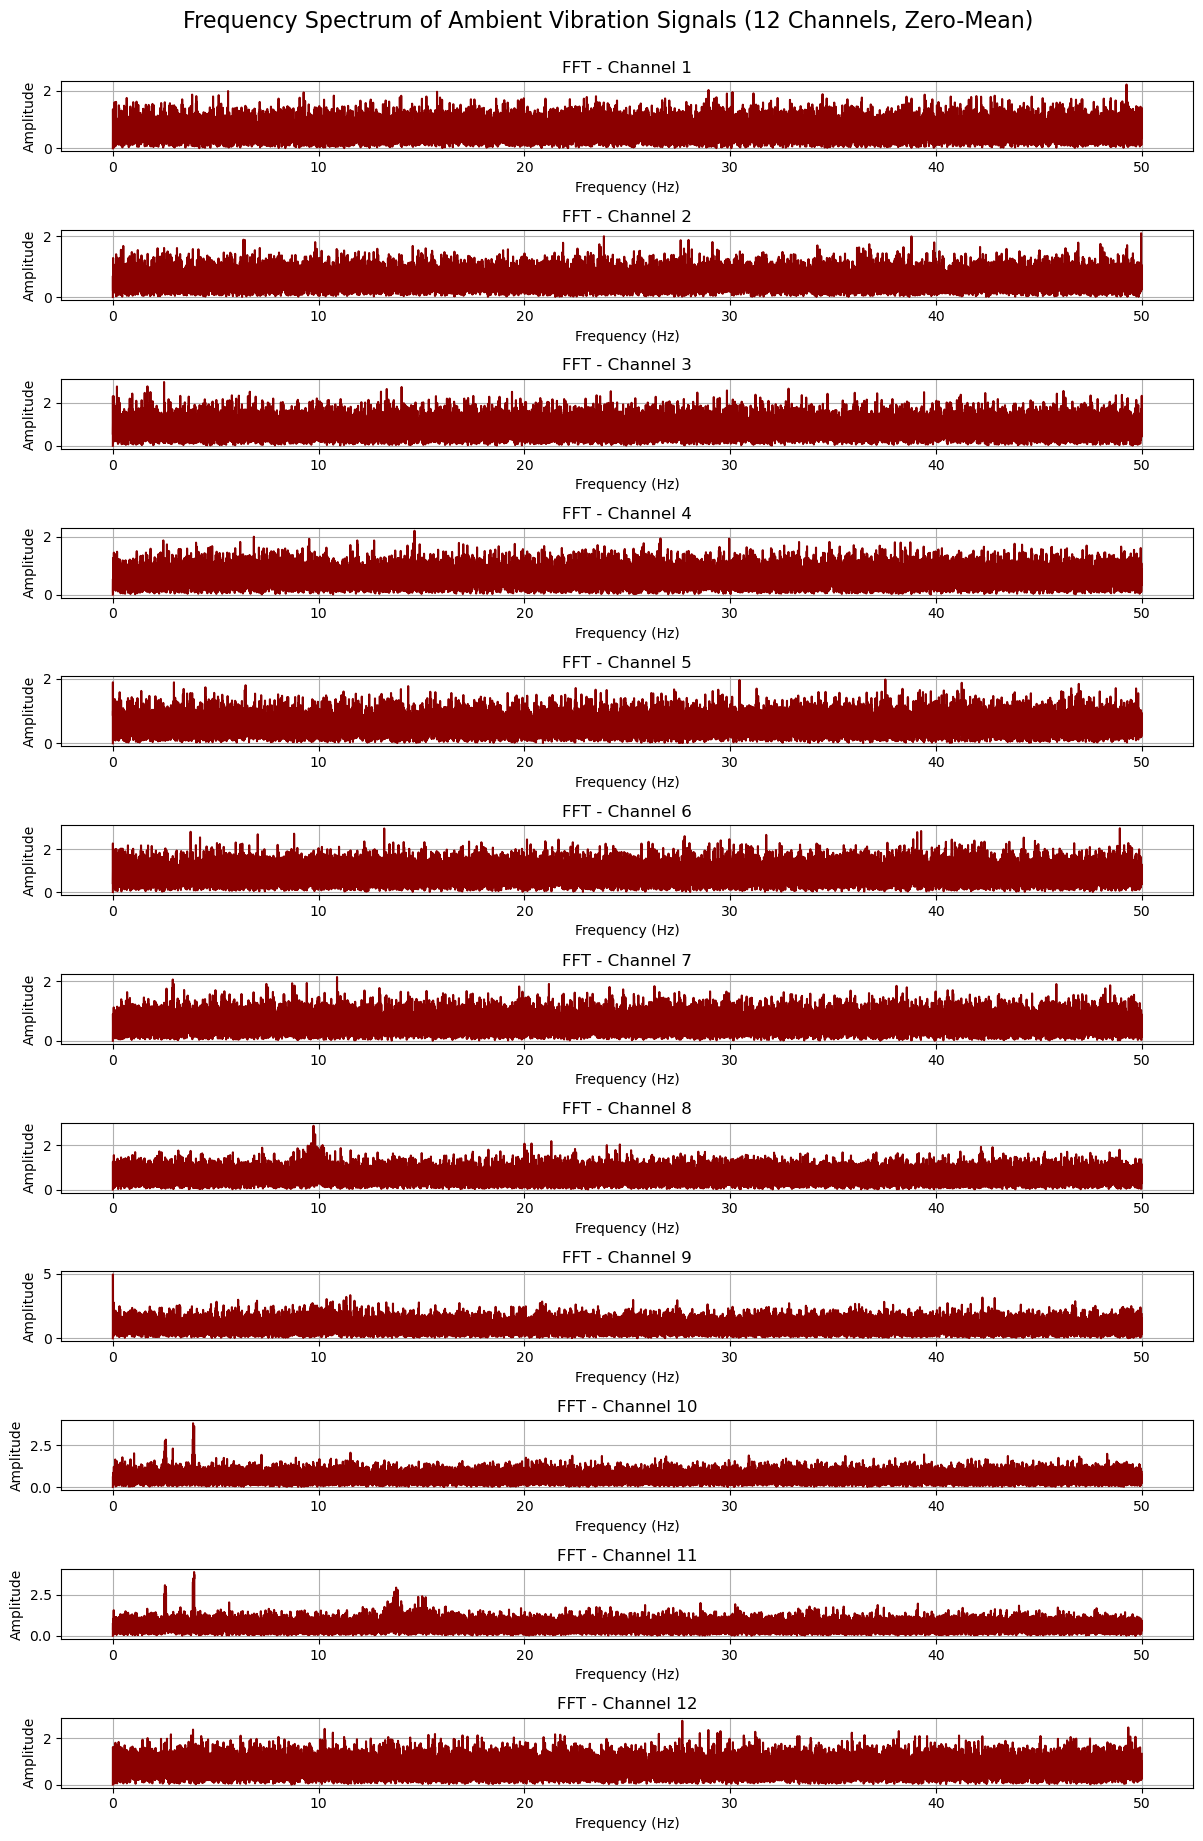

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling frequency
fs = 100  # Hz
n_samples = ambient_vib_wsn.shape[0]
n_channels = ambient_vib_wsn.shape[1]

# Step 1: Remove DC offset (zero-mean)
ambient_vib_wsn_zero_mean = ambient_vib_wsn - np.mean(ambient_vib_wsn, axis=0)

# Step 2: Frequency axis (one-sided)
freqs = np.fft.rfftfreq(n_samples, d=1/fs)

# Step 3: Compute FFT and magnitude spectrum for each channel
fft_data = [np.abs(np.fft.rfft(ambient_vib_wsn_zero_mean[:, i])) for i in range(n_channels)]

# Step 4: Plot FFT results in 12x1 subplots
plt.figure(figsize=(12, 18))  # Wide and tall figure

for i in range(n_channels):
    plt.subplot(12, 1, i + 1)
    plt.plot(freqs, fft_data[i], color='darkred')
    plt.title(f"FFT - Channel {i+1}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Frequency Spectrum of Ambient Vibration Signals (12 Channels, Zero-Mean)", fontsize=16, y=1.02)
plt.show()
